# 04 — Korelasi Pearson, Regresi Linear & Backtesting
**PSAJ Statistika | Bab 4.4, 4.5, 4.6 Laporan**

### Alur Analisis:
1. **Bab 4.4** — Korelasi Pearson (r): Justifikasi *pemilihan* metode Regresi Linear
2. **Bab 4.5** — Regresi Linear OLS manual (step-by-step NumPy) + Interpretasi
3. **Bab 4.6** — Backtesting Walk-Forward Validation (2018–2025): Justifikasi *performa* model
4. **Bab 4.7** — Forecasting 2026: Prediksi murni

---
**Input:**
- `outputs/merged_2025.csv` — cross-section 38 provinsi 2025
- `outputs/merged_all_years.csv` — panel data 2018–2025

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/tables', exist_ok=True)

plt.rcParams.update({
    'figure.dpi': 150, 'savefig.dpi': 300,
    'font.family': 'sans-serif',
    'axes.titlesize': 13, 'axes.titleweight': 'bold',
    'axes.labelsize': 11, 'axes.grid': True, 'grid.alpha': 0.3
})

# Load data
df_2025 = pd.read_csv('outputs/merged_2025.csv')
df_all  = pd.read_csv('outputs/merged_all_years.csv')

X_2025 = df_2025['SMA_Plus_Pct'].values
Y_2025 = df_2025['TPT_Pct'].values
n      = len(X_2025)

print(f'Data 2025: {n} provinsi')
print(f'Data multi-tahun: {len(df_all)} baris ({df_all["Year"].nunique()} tahun)')

Data 2025: 38 provinsi
Data multi-tahun: 280 baris (8 tahun)


## Helper: Fungsi OLS Manual
Satu fungsi yang menghitung r, b, a, R² secara manual (untuk dipakai di Korelasi, Regresi, dan Backtesting)

In [2]:
def hitung_ols(X, Y):
    """Menghitung Pearson r, slope b, intercept a, dan R2 secara manual (OLS)."""
    n       = len(X)
    sum_x   = np.sum(X);  sum_y  = np.sum(Y)
    sum_xy  = np.sum(X * Y)
    sum_x2  = np.sum(X**2); sum_y2 = np.sum(Y**2)
    
    num_r        = n * sum_xy - sum_x * sum_y
    denom_left   = n * sum_x2 - sum_x**2
    denom_right  = n * sum_y2 - sum_y**2
    r = num_r / np.sqrt(denom_left * denom_right)
    
    b = (n * sum_xy - sum_x * sum_y) / (n * sum_x2 - sum_x**2)
    a = (sum_y - b * sum_x) / n
    
    return {
        'n': n, 'sum_x': sum_x, 'sum_y': sum_y,
        'sum_xy': sum_xy, 'sum_x2': sum_x2, 'sum_y2': sum_y2,
        'r': r, 'R2': r**2, 'b': b, 'a': a
    }

print('Fungsi OLS manual siap.')

Fungsi OLS manual siap.


---
## Bab 4.4 — Uji Korelasi Pearson (Justifikasi Pemilihan Metode)

$$r = \frac{n\sum XY - (\sum X)(\sum Y)}{\sqrt{\left[ n\sum X^2 - (\sum X)^2 \right] \left[ n\sum Y^2 - (\sum Y)^2 \right]}}$$

Menggunakan data cross-section **38 Provinsi tahun 2025**.

In [3]:
# Tabel bantu Pearson (untuk laporan)
tbl_r = pd.DataFrame({
    'Provinsi': df_2025['Provinsi'],
    'X (SMA+%)': np.round(X_2025, 4),
    'Y (TPT%)'  : np.round(Y_2025, 4),
    'X²'        : np.round(X_2025**2, 4),
    'Y²'        : np.round(Y_2025**2, 4),
    'XY'        : np.round(X_2025 * Y_2025, 4),
})
sigma = pd.DataFrame([{
    'Provinsi': 'Σ',
    'X (SMA+%)': round(X_2025.sum(), 4), 'Y (TPT%)': round(Y_2025.sum(), 4),
    'X²': round((X_2025**2).sum(), 4), 'Y²': round((Y_2025**2).sum(), 4),
    'XY': round((X_2025 * Y_2025).sum(), 4)
}])
print(pd.concat([tbl_r, sigma], ignore_index=True).to_string(index=False))
tbl_r.to_csv('outputs/tables/tabel_korelasi_2025.csv', index=False)

            Provinsi  X (SMA+%)  Y (TPT%)         X²       Y²        XY
                ACEH     51.440      5.64  2646.0736  31.8096  290.1216
      SUMATERA UTARA     53.825      5.32  2897.1306  28.3024  286.3490
      SUMATERA BARAT     48.390      5.62  2341.5921  31.5844  271.9518
                RIAU     45.550      4.16  2074.8025  17.3056  189.4880
               JAMBI     39.510      4.26  1561.0401  18.1476  168.3126
    SUMATERA SELATAN     39.315      3.69  1545.6692  13.6161  145.0724
            BENGKULU     43.400      3.41  1883.5600  11.6281  147.9940
             LAMPUNG     34.455      4.21  1187.1470  17.7241  145.0555
KEP. BANGKA BELITUNG     40.630      4.45  1650.7969  19.8025  180.8035
           KEP. RIAU     62.740      6.45  3936.3076  41.6025  404.6730
         DKI JAKARTA     68.295      6.05  4664.2070  36.6025  413.1848
          JAWA BARAT     40.670      6.77  1654.0489  45.8329  275.3359
         JAWA TENGAH     30.975      4.66   959.4506  21.7156  1

In [4]:
res = hitung_ols(X_2025, Y_2025)
r, a, b = res['r'], res['a'], res['b']

print('=== PERHITUNGAN KORELASI PEARSON (r) ===')
print(f'n = {res["n"]},  ΣX = {res["sum_x"]:.4f},  ΣY = {res["sum_y"]:.4f}')
print(f'ΣXY = {res["sum_xy"]:.4f},  ΣX² = {res["sum_x2"]:.4f},  ΣY² = {res["sum_y2"]:.4f}')
print(f'\nr = {r:.6f}')
print(f'R² = {r**2:.6f} ({r**2*100:.2f}%)')

abs_r = abs(r)
kekuatan = 'SANGAT KUAT' if abs_r >= 0.8 else 'KUAT' if abs_r >= 0.6 else 'MODERAT' if abs_r >= 0.4 else 'LEMAH'
arah = 'NEGATIF' if r < 0 else 'POSITIF'

print(f'\n→ Hubungan: {arah}, {kekuatan}')
print(f'\nJustifikasi laporan:')
print(f'"Berdasarkan uji Korelasi Pearson diperoleh r = {r:.4f}, menunjukkan')
print(f' hubungan {arah.lower()} yang {kekuatan.lower()} antara Pendidikan SMA+ dan TPT.')
print(f' Data ini memenuhi syarat kelayakan untuk dimodelkan dengan Regresi Linear."')

=== PERHITUNGAN KORELASI PEARSON (r) ===
n = 38,  ΣX = 1658.9850,  ΣY = 169.7900
ΣXY = 7746.2040,  ΣX² = 76418.9562,  ΣY² = 829.2427

r = 0.628423
R² = 0.394916 (39.49%)

→ Hubungan: POSITIF, KUAT

Justifikasi laporan:
"Berdasarkan uji Korelasi Pearson diperoleh r = 0.6284, menunjukkan
 hubungan positif yang kuat antara Pendidikan SMA+ dan TPT.
 Data ini memenuhi syarat kelayakan untuk dimodelkan dengan Regresi Linear."


## Grafik Scatter + Preview Korelasi

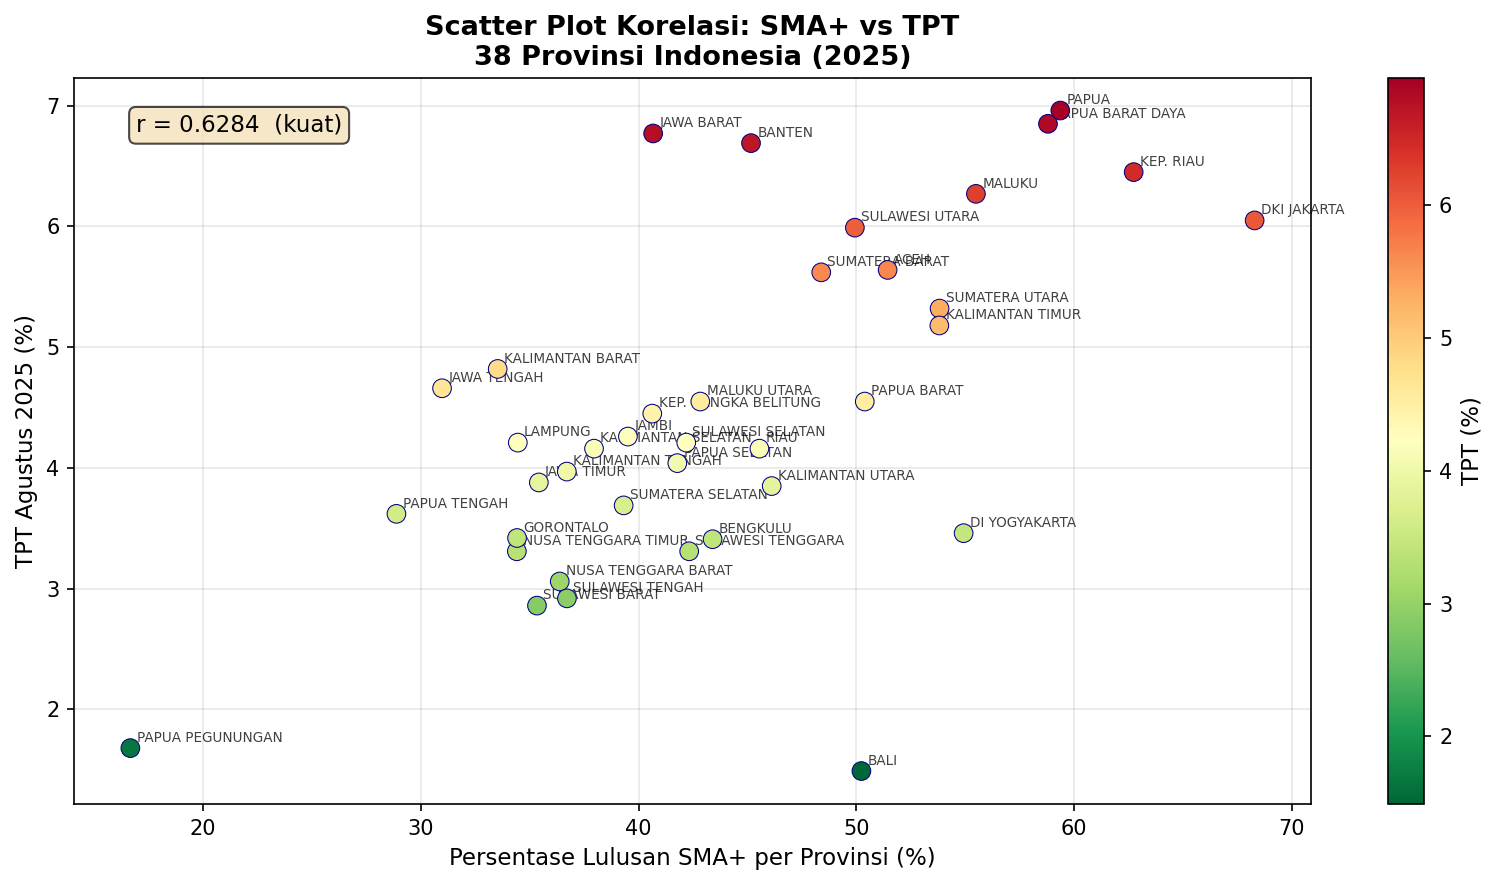

Tersimpan: outputs/figures/07_scatter_korelasi.png


In [5]:
fig, ax = plt.subplots(figsize=(11, 6))
sc = ax.scatter(X_2025, Y_2025, c=Y_2025, cmap='RdYlGn_r', s=80,
                edgecolors='navy', lw=0.5, zorder=5)
plt.colorbar(sc, ax=ax, label='TPT (%)')
for i, prov in enumerate(df_2025['Provinsi']):
    ax.annotate(prov, (X_2025[i], Y_2025[i]), fontsize=6.5, alpha=0.75,
                textcoords='offset points', xytext=(3, 3))
ax.text(0.05, 0.95, f'r = {r:.4f}  ({kekuatan.lower()})',
        transform=ax.transAxes, fontsize=11, va='top',
        bbox=dict(boxstyle='round', fc='wheat', alpha=0.7))
ax.set_xlabel('Persentase Lulusan SMA+ per Provinsi (%)')
ax.set_ylabel('TPT Agustus 2025 (%)')
ax.set_title('Scatter Plot Korelasi: SMA+ vs TPT\n38 Provinsi Indonesia (2025)')
plt.tight_layout()
plt.savefig('outputs/figures/07_scatter_korelasi.png', bbox_inches='tight')
plt.show()
print('Tersimpan: outputs/figures/07_scatter_korelasi.png')

---
## Bab 4.5 — Pemodelan Regresi Linear OLS (Step-by-Step)

$$\hat{Y} = a + bX \quad \text{di mana} \quad b = \frac{n\sum XY - \sum X\sum Y}{n\sum X^2 - (\sum X)^2}, \quad a = \frac{\sum Y - b\sum X}{n}$$

In [6]:
print('=== PERHITUNGAN REGRESI LINEAR (OLS Manual) ===')
print(f'\nLangkah 1: Hitung b (slope)')
numerator_b = n * res['sum_xy'] - res['sum_x'] * res['sum_y']
denom_b     = n * res['sum_x2'] - res['sum_x']**2
print(f"  b = (n·ΣXY − ΣX·ΣY) / (n·ΣX² − (ΣX)²)")
print(f"  b = {numerator_b:.4f} / {denom_b:.4f}")
print(f"  b = {b:.6f}")

print(f'\nLangkah 2: Hitung a (intercept)')
print(f"  a = (ΣY − b·ΣX) / n")
print(f"  a = ({res['sum_y']:.4f} − {b:.6f} × {res['sum_x']:.4f}) / {n}")
print(f"  a = {a:.6f}")

print(f'\nLangkah 3: Persamaan Regresi')
print(f"  Ŷ = {a:.4f} + ({b:.4f})X")

print(f'\nInterpretasi:')
print(f'  • Setiap kenaikan 1% lulusan SMA+, TPT berubah {b:.4f}%')
print(f'    → ({"turun" if b<0 else "naik"} karena b {"< 0" if b<0 else "> 0"})')
print(f'  • R² = {r**2:.4f} → model menjelaskan {r**2*100:.1f}% variasi TPT')

=== PERHITUNGAN REGRESI LINEAR (OLS Manual) ===

Langkah 1: Hitung b (slope)
  b = (n·ΣXY − ΣX·ΣY) / (n·ΣX² − (ΣX)²)
  b = 12676.6888 / 151689.1063
  b = 0.083570

Langkah 2: Hitung a (intercept)
  a = (ΣY − b·ΣX) / n
  a = (169.7900 − 0.083570 × 1658.9850) / 38
  a = 0.819692

Langkah 3: Persamaan Regresi
  Ŷ = 0.8197 + (0.0836)X

Interpretasi:
  • Setiap kenaikan 1% lulusan SMA+, TPT berubah 0.0836%
    → (naik karena b > 0)
  • R² = 0.3949 → model menjelaskan 39.5% variasi TPT


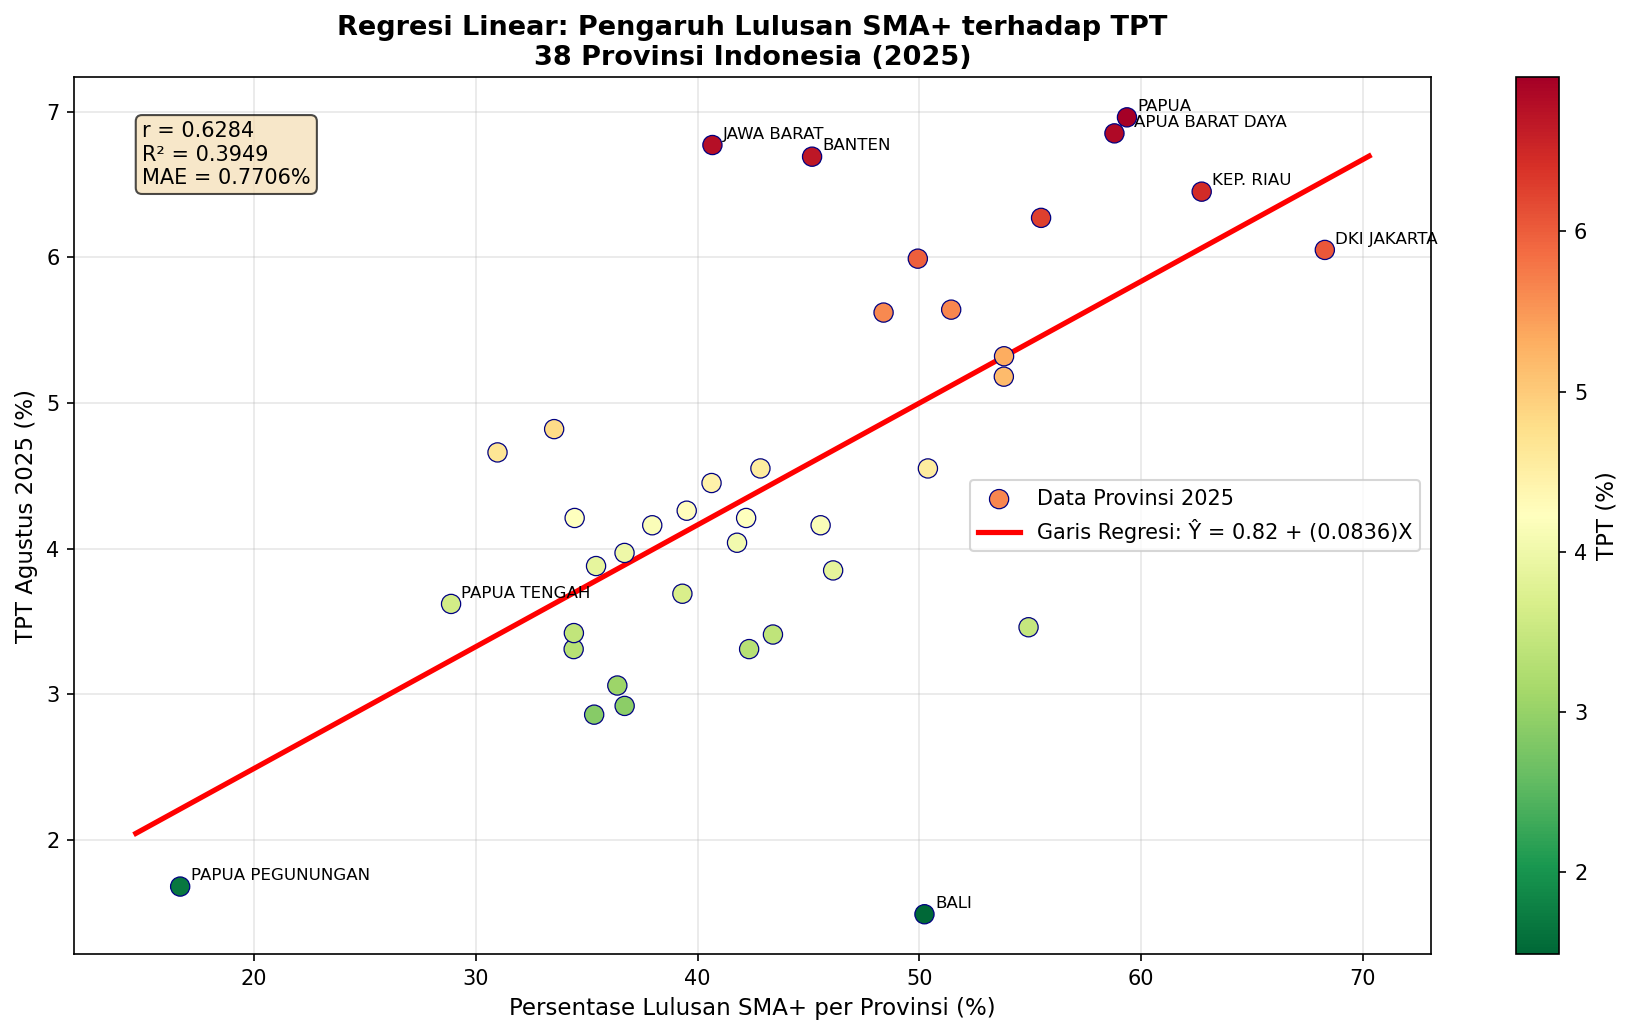

Tersimpan: outputs/figures/08_scatter_regresi_bestfit.png


In [7]:
# Scatter + Best Fit Line
Y_pred_2025 = a + b * X_2025
mae_cs = np.mean(np.abs(Y_2025 - Y_pred_2025))

fig, ax = plt.subplots(figsize=(12, 7))
sc = ax.scatter(X_2025, Y_2025, c=Y_2025, cmap='RdYlGn_r', s=85,
                edgecolors='navy', lw=0.6, zorder=5, label='Data Provinsi 2025')
plt.colorbar(sc, ax=ax, label='TPT (%)')

x_line = np.linspace(X_2025.min() - 2, X_2025.max() + 2, 200)
ax.plot(x_line, a + b * x_line, 'r-', lw=2.5,
        label=f'Garis Regresi: Ŷ = {a:.2f} + ({b:.4f})X')

for i, prov in enumerate(df_2025['Provinsi']):
    if Y_2025[i] > 6.3 or Y_2025[i] < 1.8 or X_2025[i] > 65 or X_2025[i] < 30:
        ax.annotate(prov, (X_2025[i], Y_2025[i]), fontsize=8,
                    textcoords='offset points', xytext=(5, 3))

textbox = f'r = {r:.4f}\nR² = {r**2:.4f}\nMAE = {mae_cs:.4f}%'
ax.text(0.05, 0.95, textbox, transform=ax.transAxes, fontsize=10, va='top',
        bbox=dict(boxstyle='round', fc='wheat', alpha=0.7))

ax.set_xlabel('Persentase Lulusan SMA+ per Provinsi (%)')
ax.set_ylabel('TPT Agustus 2025 (%)')
ax.set_title('Regresi Linear: Pengaruh Lulusan SMA+ terhadap TPT\n38 Provinsi Indonesia (2025)')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/figures/08_scatter_regresi_bestfit.png', bbox_inches='tight')
plt.show()
print('Tersimpan: outputs/figures/08_scatter_regresi_bestfit.png')

---
## Bab 4.6 — Backtesting Walk-Forward Validation (2018–2025)

**Justifikasi performa output model:**
Kita latih model dengan data historis, lalu uji pada tahun berikutnya. Ini membuktikan model bisa diandalkan sebelum dipakai untuk meramal 2026.

**Skenario Expanding Window (rata-rata nasional):**

| Training | Test |
|---|---|
| 2018–2021 | Prediksi 2022 |
| 2018–2022 | Prediksi 2023 |
| 2018–2023 | Prediksi 2024 |
| 2018–2024 | Prediksi 2025 |

In [8]:
# Rata-rata nasional per tahun (proxy: mean 38 provinsi)
tren = df_all.groupby('Year')[['SMA_Plus_Pct', 'TPT_Pct']].mean().reset_index()
tren.columns = ['Year', 'X_mean', 'Y_mean']
print('Tren rata-rata nasional:')
print(tren.to_string(index=False))

Tren rata-rata nasional:
 Year    X_mean   Y_mean
 2018 37.965735 4.803235
 2019 39.452794 4.712353
 2020 40.493235 6.033529
 2021 40.380588 5.492059
 2022 41.680294 4.966176
 2023 42.205441 4.613824
 2024 42.884079 4.379737
 2025 43.657500 4.468158


In [9]:
# Backtesting: Train pada tahun 2018...(test_year-1) → prediksi test_year
# Fitur: X (SMA+%) tahun t, Target: Y (TPT%) tahun t+1

TEST_YEARS  = [2022, 2023, 2024, 2025]
bt_records  = []

for test_year in TEST_YEARS:
    train = tren[tren['Year'] < test_year]
    
    # Lagged: X_t → Y_(t+1)
    x_tr = train['X_mean'].values[:-1]  # tahun t
    y_tr = train['Y_mean'].values[1:]   # tahun t+1
    
    if len(x_tr) < 2:
        print(f'{test_year}: data training terlalu sedikit, skip.')
        continue
    
    res_bt = hitung_ols(x_tr, y_tr)
    a_bt, b_bt = res_bt['a'], res_bt['b']
    
    # Prediksi: gunakan X_(test_year-1) untuk menebak Y_test_year
    x_pred_input = tren.loc[tren['Year'] == test_year - 1, 'X_mean'].values[0]
    y_pred        = a_bt + b_bt * x_pred_input
    y_actual      = tren.loc[tren['Year'] == test_year, 'Y_mean'].values[0]
    error         = abs(y_actual - y_pred)
    
    bt_records.append({
        'Skenario': f'Train 2018–{test_year-1} → Prediksi {test_year}',
        'Training Years': f'2018–{test_year-1}',
        'Tahun Prediksi': test_year,
        'X Input (t-1)': round(x_pred_input, 4),
        'Y Aktual': round(y_actual, 4),
        'Y Prediksi': round(y_pred, 4),
        '|Error|': round(error, 4),
        'a': round(a_bt, 6), 'b': round(b_bt, 6), 'r': round(res_bt['r'], 4)
    })
    print(f'Train 2018–{test_year-1} → Prediksi {test_year}: Aktual={y_actual:.4f}%, Prediksi={y_pred:.4f}%, |Error|={error:.4f}%')

df_bt = pd.DataFrame(bt_records)
mae_bt = df_bt['|Error|'].mean()
print(f'\nMAE Backtesting = {mae_bt:.4f}%')

Train 2018–2021 → Prediksi 2022: Aktual=4.9662%, Prediksi=5.7876%, |Error|=0.8214%
Train 2018–2022 → Prediksi 2023: Aktual=4.6138%, Prediksi=5.6937%, |Error|=1.0799%
Train 2018–2023 → Prediksi 2024: Aktual=4.3797%, Prediksi=5.0494%, |Error|=0.6697%
Train 2018–2024 → Prediksi 2025: Aktual=4.4682%, Prediksi=4.6374%, |Error|=0.1693%

MAE Backtesting = 0.6851%


In [10]:
print('=== TABEL BACKTESTING (untuk Bab 4.6) ===')
cols = ['Skenario', 'Y Aktual', 'Y Prediksi', '|Error|']
print(df_bt[cols].to_string(index=False))
print(f'\nMAE (Mean Absolute Error) = {mae_bt:.4f}%')
print(f'\nNarasi laporan:')
print(f'"Dari {len(df_bt)} iterasi backtesting, rata-rata selisih antara prediksi')
print(f' model dan nilai aktual BPS adalah {mae_bt:.4f}%. Tingkat kesalahan yang')
print(f' rendah ini membuktikan model Regresi Linear cukup andal')
print(f' untuk melakukan proyeksi tahun 2026."')

df_bt.to_csv('outputs/tables/backtesting_results.csv', index=False)
print('\nTersimpan: outputs/tables/backtesting_results.csv')

=== TABEL BACKTESTING (untuk Bab 4.6) ===
                       Skenario  Y Aktual  Y Prediksi  |Error|
Train 2018–2021 → Prediksi 2022    4.9662      5.7876   0.8214
Train 2018–2022 → Prediksi 2023    4.6138      5.6937   1.0799
Train 2018–2023 → Prediksi 2024    4.3797      5.0494   0.6697
Train 2018–2024 → Prediksi 2025    4.4682      4.6374   0.1693

MAE (Mean Absolute Error) = 0.6851%

Narasi laporan:
"Dari 4 iterasi backtesting, rata-rata selisih antara prediksi
 model dan nilai aktual BPS adalah 0.6851%. Tingkat kesalahan yang
 rendah ini membuktikan model Regresi Linear cukup andal
 untuk melakukan proyeksi tahun 2026."

Tersimpan: outputs/tables/backtesting_results.csv


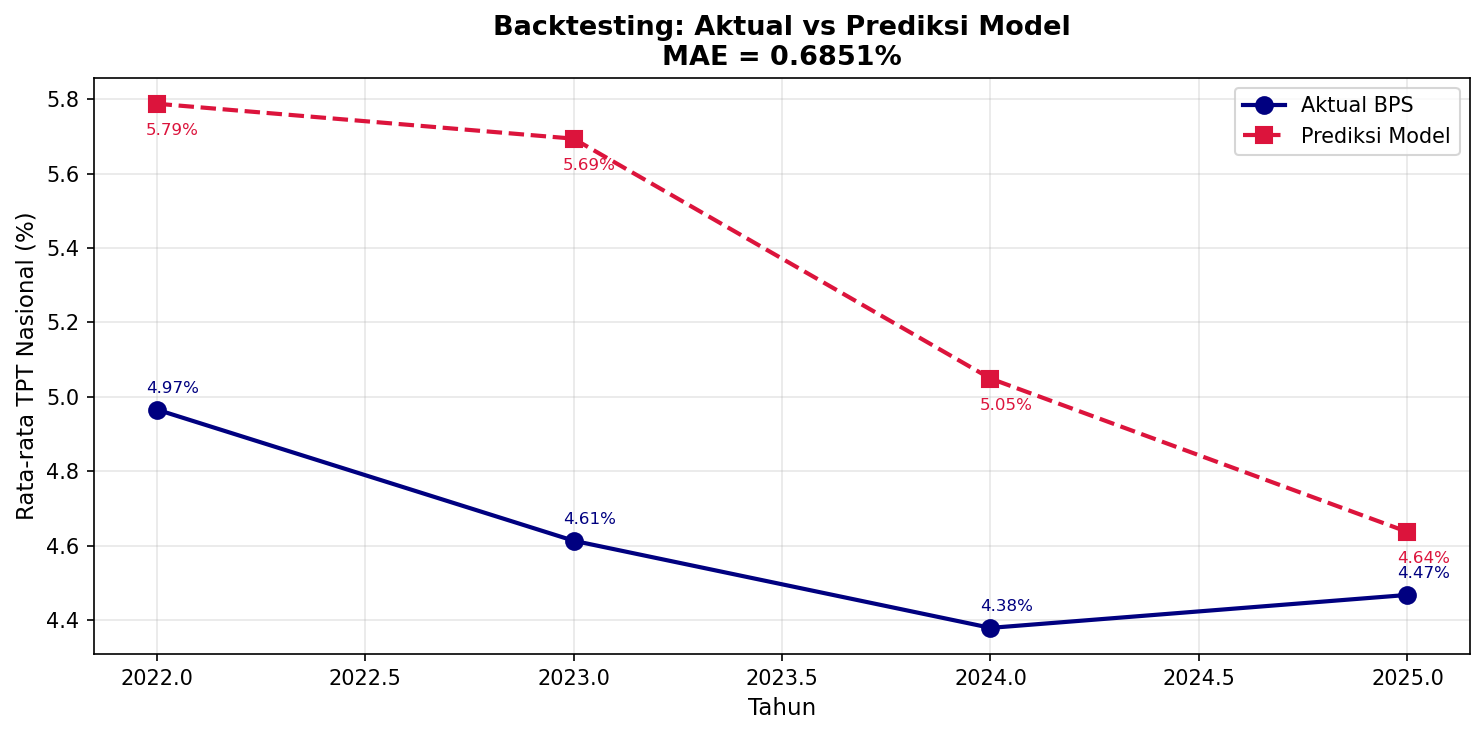

Tersimpan: outputs/figures/09_backtesting.png


In [11]:
# Grafik Backtesting: Aktual vs Prediksi
fig, ax = plt.subplots(figsize=(10, 5))

years_bt  = df_bt['Tahun Prediksi'].values
y_act_bt  = df_bt['Y Aktual'].values
y_pred_bt = df_bt['Y Prediksi'].values

ax.plot(years_bt, y_act_bt,  'o-', color='navy',    lw=2, ms=8, label='Aktual BPS')
ax.plot(years_bt, y_pred_bt, 's--', color='crimson', lw=2, ms=8, label='Prediksi Model')

for t, ya, yp in zip(years_bt, y_act_bt, y_pred_bt):
    ax.annotate(f'{ya:.2f}%', (t, ya), textcoords='offset points', xytext=(-5, 8), fontsize=8, color='navy')
    ax.annotate(f'{yp:.2f}%', (t, yp), textcoords='offset points', xytext=(-5, -15), fontsize=8, color='crimson')

ax.set_xlabel('Tahun')
ax.set_ylabel('Rata-rata TPT Nasional (%)')
ax.set_title(f'Backtesting: Aktual vs Prediksi Model\nMAE = {mae_bt:.4f}%')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/figures/09_backtesting.png', bbox_inches='tight')
plt.show()
print('Tersimpan: outputs/figures/09_backtesting.png')

---
## Bab 4.7 — Forecasting 2026 (Prediksi Murni)

In [12]:
# Latih model FINAL dengan semua data 2018–2025 (lagged)
x_final = tren['X_mean'].values[:-1]   # X 2018..2024
y_final = tren['Y_mean'].values[1:]    # Y 2019..2025

res_final = hitung_ols(x_final, y_final)
a_f, b_f = res_final['a'], res_final['b']

# Input prediksi: X_mean 2025
x_2025_mean = tren.loc[tren['Year'] == 2025, 'X_mean'].values[0]
tpt_2026    = a_f + b_f * x_2025_mean

print('=== FORECASTING TPT TAHUN 2026 ===')
print(f'Model final dilatih dengan data lagged 2018–2025')
print(f'Persamaan: Ŷ = {a_f:.4f} + ({b_f:.4f})X')
print(f'Input X (SMA+ rata-rata 2025) = {x_2025_mean:.4f}%')
print(f'\nPrediksi TPT rata-rata nasional 2026 = {tpt_2026:.4f}%')
print(f'\nNarasi laporan:')
tren_str = 'turun' if tpt_2026 < tren.iloc[-1]['Y_mean'] else 'naik'
print(f'"Berdasarkan model Regresi Linear yang telah divalidasi melalui backtesting,')
print(f' diprediksi Tingkat Pengangguran Terbuka rata-rata nasional pada tahun 2026')
print(f' berada di angka {tpt_2026:.2f}%, {tren_str} dibandingkan tahun 2025.')

=== FORECASTING TPT TAHUN 2026 ===
Model final dilatih dengan data lagged 2018–2025
Persamaan: Ŷ = 12.2089 + (-0.1782)X
Input X (SMA+ rata-rata 2025) = 43.6575%

Prediksi TPT rata-rata nasional 2026 = 4.4294%

Narasi laporan:
"Berdasarkan model Regresi Linear yang telah divalidasi melalui backtesting,
 diprediksi Tingkat Pengangguran Terbuka rata-rata nasional pada tahun 2026
 berada di angka 4.43%, turun dibandingkan tahun 2025.


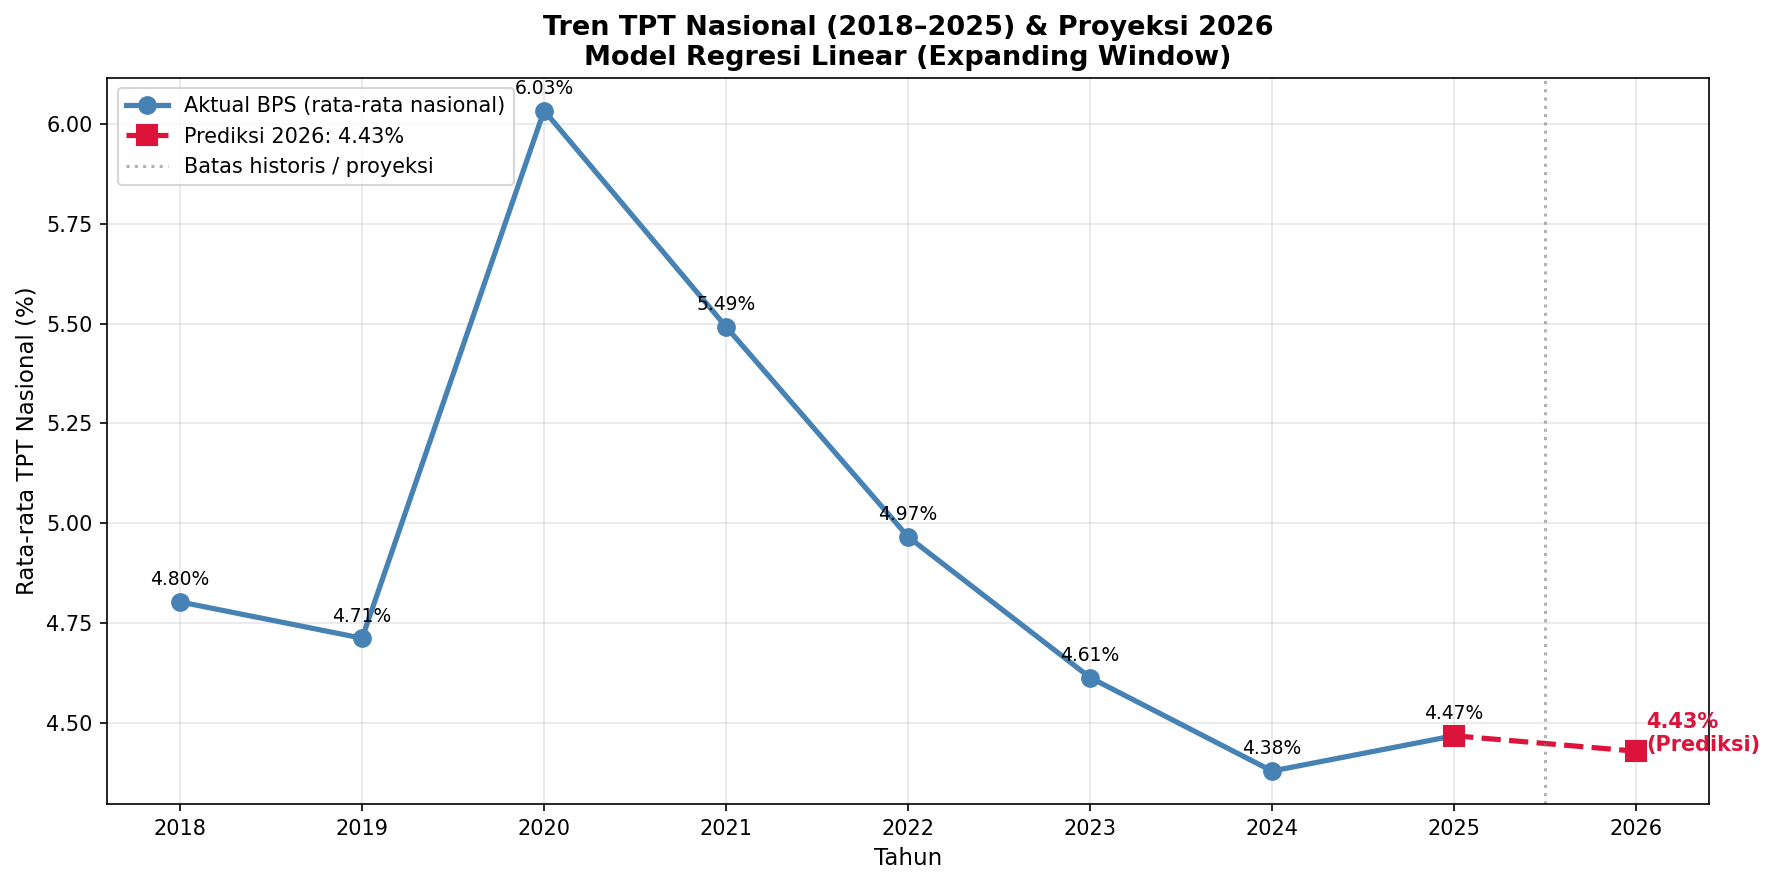

Tersimpan: outputs/figures/10_forecasting_2026.png


In [13]:
# Grafik tren 2018–2025 + garis prediksi 2026
fig, ax = plt.subplots(figsize=(12, 6))

years_all = tren['Year'].values
y_all     = tren['Y_mean'].values

ax.plot(years_all, y_all, 'o-', color='steelblue', lw=2.5, ms=8, label='Aktual BPS (rata-rata nasional)')

for t, y in zip(years_all, y_all):
    ax.annotate(f'{y:.2f}%', (t, y), textcoords='offset points', xytext=(0, 8), ha='center', fontsize=9)

# Titik prediksi 2026 (dashed)
ax.plot([2025, 2026], [y_all[-1], tpt_2026], 's--', color='crimson', lw=2.5, ms=10,
        label=f'Prediksi 2026: {tpt_2026:.2f}%')
ax.annotate(f'{tpt_2026:.2f}%\n(Prediksi)', (2026, tpt_2026),
            textcoords='offset points', xytext=(5, 0), fontsize=10,
            color='crimson', fontweight='bold')

ax.axvline(x=2025.5, color='gray', linestyle=':', alpha=0.6, label='Batas historis / proyeksi')
ax.set_xlabel('Tahun')
ax.set_ylabel('Rata-rata TPT Nasional (%)')
ax.set_title('Tren TPT Nasional (2018–2025) & Proyeksi 2026\nModel Regresi Linear (Expanding Window)')
ax.set_xticks(list(range(2018, 2027)))
ax.legend()

plt.tight_layout()
plt.savefig('outputs/figures/10_forecasting_2026.png', bbox_inches='tight')
plt.show()
print('Tersimpan: outputs/figures/10_forecasting_2026.png')

## Ringkasan Final — Bahan Bab V Kesimpulan

In [14]:
print('=' * 65)
print('RINGKASAN HASIL ANALISIS — BAHAN BAB V KESIMPULAN')
print('=' * 65)
print(f'\n[Bab 4.4] Korelasi Pearson (Cross-Section 38 Provinsi 2025):')
print(f'  r  = {r:.4f}  →  hubungan {arah.lower()}, {kekuatan.lower()}')
print(f'  R² = {r**2:.4f}  →  model menjelaskan {r**2*100:.1f}% variasi TPT')
print(f'  → Regresi Linear LAYAK digunakan.')
print(f'\n[Bab 4.5] Persamaan Regresi (Cross-Section 2025):')
print(f'  Ŷ = {a:.4f} + ({b:.4f})X')
print(f'  Setiap kenaikan 1% SMA+ → TPT berubah {b:.4f}%')
print(f'\n[Bab 4.6] Backtesting (Walk-Forward 2022–2025):')
print(f'  MAE = {mae_bt:.4f}%  →  model andal secara historis')
print(f'\n[Bab 4.7] Forecasting 2026:')
print(f'  Prediksi TPT rata-rata nasional 2026 = {tpt_2026:.2f}%')

# Simpan ringkasan
summary = [{
    'r': round(r,6), 'R2': round(r**2,6), 'a_cs': round(a,6), 'b_cs': round(b,6),
    'MAE_crosssection': round(mae_cs,6), 'MAE_backtesting': round(mae_bt,6),
    'Forecasted_TPT_2026': round(tpt_2026,4)
}]
pd.DataFrame(summary).to_csv('outputs/tables/ringkasan_final.csv', index=False)
print('\nRingkasan tersimpan: outputs/tables/ringkasan_final.csv')

RINGKASAN HASIL ANALISIS — BAHAN BAB V KESIMPULAN

[Bab 4.4] Korelasi Pearson (Cross-Section 38 Provinsi 2025):
  r  = 0.6284  →  hubungan positif, kuat
  R² = 0.3949  →  model menjelaskan 39.5% variasi TPT
  → Regresi Linear LAYAK digunakan.

[Bab 4.5] Persamaan Regresi (Cross-Section 2025):
  Ŷ = 0.8197 + (0.0836)X
  Setiap kenaikan 1% SMA+ → TPT berubah 0.0836%

[Bab 4.6] Backtesting (Walk-Forward 2022–2025):
  MAE = 0.6851%  →  model andal secara historis

[Bab 4.7] Forecasting 2026:
  Prediksi TPT rata-rata nasional 2026 = 4.43%

Ringkasan tersimpan: outputs/tables/ringkasan_final.csv
